## Integrantes

Raful Habib Sánchez Morales — A01127380  
Efrén Alejandro Barroso Llanes — A01795861  
Michelle Alicia Graver Aguilar — A01242013

# Avance 1. Análisis Exploratorio de Datos

# Avance 5. Modelo final (Modelos de Ensamble)




## Índice — Modelo Final

34. Justificación de las Estrategias de Ensamble  
35. Configuración y Entrenamiento de los Modelos de Ensamble  
   - 35.1 Imports y Carga de Modelos entrenados  
   - 35.2 Modelos base para ensambles heterogéneos  
   - 35.3 Optimización de hiperparámetros — Random Forest  
   - 35.4 Definición de los 4 modelos de ensamble  
   - 35.5 Entrenamiento cronometrado  
36. Tabla Comparativa Completa (Individuales + Ensambles)  
   - 36.1 Tabla comparativa con métricas y tiempos  
   - 36.2 Visualización comparativa  
37. Selección del Modelo Final  
   - 37.1 Argumentación y criterios de negocio  
   - 37.2 Decisión final  
38. Análisis del Modelo Final  
   - 38.1 Curva ROC  
   - 38.2 Matriz de confusión  
   - 38.3 Curva Precisión-Recall  
   - 38.4 Importancia de características / coeficientes  
   - 38.5 Curva de aprendizaje
39. Conclusiones
40. Bibliografía

---
## 34. Justificación de las Estrategias de Ensamble

Los modelos de ensamble combinan múltiples estimadores para superar las limitaciones de los modelos individuales mediante dos mecanismos principales: reducir la varianza mediante submuestreo con reemplazo (Bagging), o aprovechar la diversidad de paradigmas combinando modelos distintos (Voting/Stacking) [1]. En este avance se implementan **4 ensambles** cubriendo obligatoriamente estrategias homogéneas y heterogéneas.

No se implementa Boosting dado que los modelos individuales de la Parte IV no constituyen aprendices débiles (*weak learners*) (requisito conceptual del paradigma Boosting según Singh [1]) sino modelos con alta capacidad predictiva individual (AUC-ROC > 0.98), por lo que el mecanismo de corrección iterativa de errores que
caracteriza al Boosting no aportaría ventaja sobre el enfoque adoptado.

### Estrategias Implementadas

| # | Nombre | Clase sklearn | Estrategia | Paradigma | Justificación para Psoriasis |
|---|---|---|---|---|---|
| 1 | **BAG_SVM** | `BaggingClassifier` | Homogénea — Bagging | Mismo algoritmo (SVM RBF) + bootstrap de muestras | Reduce la varianza del mejor modelo individual (SVM RBF + FULL); reutiliza los hiperparámetros óptimos hallados en la Parte IV [2] |
| 2 | **RF_FT** | `RandomForestClassifier` | Homogénea — Bagging con aleatoriedad de características | Múltiples árboles con subconjunto aleatorio de características por nodo | Eficaz en datos de expresión génica de alta dimensionalidad; genera importancia de variables interpretable sin requerir un único modelo base [1] |
| 3 | **VOTE_S** | `VotingClassifier(voting='soft')` | Heterogénea — Votación suave | Promedia probabilidades de SVM_RBF + LR_L2 + KNN | Combina paradigmas distintos (margen, probabilístico, distancia); KNN se reincorpora como modelo base ya que en este contexto el desbalance se gestiona a nivel del ensamble, no del estimador individual [1] |
| 4 | **STACK** | `StackingClassifier` | Heterogénea — Stacking | Meta-aprendiz (LR L2) aprende a combinar SVM_RBF + LR_L2 + SVM_LIN + KNN | El meta-aprendiz optimiza la combinación de paradigmas complementarios; aprovecha las fortalezas de cada estimador base sobre distintas regiones del espacio de características [1] |

> **Criterio de uso de los mejores individuales:** Los ensambles heterogéneos (VOTE_S y STACK) utilizan instancias frescas de los modelos con hiperparámetros óptimos identificados en la Parte IV (C y gamma para SVM_RBF; C para LR_L2), cumpliendo la instrucción de emplear los modelos de mejor rendimiento previo. Los hiperparámetros se recuperan dinámicamente desde los objetos serializados mediante `.get_params()`.

### Comparación de Estrategias
Las diferencias fundamentales entre ambas estrategias se resumen en la siguiente tabla, con base en Singh [1] y VanderPlas [2]:
| Aspecto | Homogénea (Bagging) | Heterogénea (Voting/Stacking) |
|---|---|---|
| **Objetivo** | Reducir varianza de un modelo potente | Combinar perspectivas de distintos paradigmas |
| **Base** | Mismo algoritmo, diferentes subconjuntos de datos y/o características | Algoritmos diferentes, mismo conjunto de entrenamiento |
| **Hiperparámetros** | Del modelo base + `n_estimators` | Independientes por modelo base |
| **Ventaja clave** | Estabilidad y robustez ante varianza muestral | Diversidad de perspectivas y reducción de error sistemático |

---
## 35. Configuración y Entrenamiento de los Modelos de Ensamble
### 35.1 Imports y Carga de Modelos entrenados

Los modelos individuales con ajuste fino obtenidos en la Parte IV se cargan desde disco mediante `joblib`, evitando reentrenar desde cero. Este enfoque es consistente con el principio de reproducibilidad del pipeline: el conjunto de test debe permanecer intocado hasta la evaluación final, y los modelos deben poder recargarse en el estado exacto en que fueron entrenados [2].

Los tres modelos cargados son los candidatos identificados en la Parte IV:

| Variable | Archivo | Descripción |
|---|---|---|
| `svm_rbf_ft` | `modelo_top1_svm_full.pkl` | SVM RBF + FULL — mejor AUC-ROC individual |
| `svm_rbf_clust_ft` | `modelo_top2_svm_clustering.pkl` | SVM RBF + CLUSTERING — segundo mejor |
| `lr_ft` | `modelo_top3_lr_full.pkl` | LR L2 + FULL — modelo seleccionado al final del Avance 4 por interpretabilidad |

> Los hiperparámetros óptimos de cada modelo se recuperan dinámicamente con `.get_params()`, eliminando la necesidad de predefinir los valores.

In [1]:
import joblib
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

from matplotlib.patches import Patch

In [2]:
from scipy.stats import loguniform

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                             f1_score, roc_curve, average_precision_score,
                              PrecisionRecallDisplay, ConfusionMatrixDisplay,
                              confusion_matrix, classification_report)
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                      learning_curve, train_test_split)

from sklearn.metrics import brier_score_loss
print('Imports cargados correctamente.')

Imports cargados correctamente.


In [3]:
# ── Constantes ───────────────────────────────────────────────────────────────
RANDOM_SEED   = 42
TEST_SIZE     = 0.2
UMBRAL_MINIMO = 0.80
NOMBRES_CLASES = ['Healthy', 'Psoriasis']
COLORES = ['#d4a843', '#8c5e0a', '#f0d080', '#5c3a00', '#b8860b']

In [4]:
# ── Carga de datos (estrategia FULL — seleccionada en Avance 3) ──────────────
DIR_DATOS   = "D:/Proyectos/Python/pi_psoriasis/data/features"
DIR_MODELOS = "D:/Proyectos/Python/pi_psoriasis/models/01_evaluation"

X_FULL = pd.read_csv(f'{DIR_DATOS}/X_FULL_completo.csv', index_col=0)
y      = pd.read_csv(f'{DIR_DATOS}/y_target.csv', index_col=0).squeeze()

X_train_t, X_test_t, y_train, y_test = train_test_split(
    X_FULL, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)

y_test_num  = y_test.map({'Healthy': 0, 'Psoriasis': 1})
y_train_num = y_train.map({'Healthy': 0, 'Psoriasis': 1})

In [5]:
tabla_ma = pd.read_csv(f'{DIR_MODELOS}/tabla_ma.csv', index_col=0)
# Cargar métricas de modelos con ajuste fino del Avance 4
with open(f'{DIR_MODELOS}/metricas_ft.json', 'r') as f:
    metricas_ft = json.load(f)

In [6]:
# Carga de 6 modelos base + full serializados del Avance 4
lr_l2_base    = joblib.load(f'{DIR_MODELOS}/modelo_base_lr_l2_full.pkl')
svm_rbf_base  = joblib.load(f'{DIR_MODELOS}/modelo_base_svm_rbf_full.pkl')
svm_lin_base  = joblib.load(f'{DIR_MODELOS}/modelo_base_svm_lin_full.pkl')
lda_base      = joblib.load(f'{DIR_MODELOS}/modelo_base_lda_full.pkl')
dt_base       = joblib.load(f'{DIR_MODELOS}/modelo_base_dt_full.pkl')
sgd_base      = joblib.load(f'{DIR_MODELOS}/modelo_base_sgd_full.pkl')

# Carga de modelos top serializados del Avance 4
svm_rbf_ft       = joblib.load(f'{DIR_MODELOS}/modelo_top1_svm_full.pkl')
svm_rbf_clust_ft = joblib.load(f'{DIR_MODELOS}/modelo_top2_svm_clustering.pkl')
lr_ft            = joblib.load(f'{DIR_MODELOS}/modelo_top3_lr_full.pkl')

# Recuperar hiperparámetros óptimos dinámicamente
svm_best_C     = svm_rbf_ft.get_params()['C']
svm_best_gamma = svm_rbf_ft.get_params()['gamma']
lr_best_C      = lr_ft.get_params()['C']

print('✅ Modelos cargados correctamente desde disco.')
print(f'  SVM_RBF (FT) : C={svm_best_C:.4f}, gamma={svm_best_gamma}')
print(f'  LR_L2   (FT) : C={lr_best_C}')
print(f'\nConjuntos: X_train_t={X_train_t.shape}, X_test_t={X_test_t.shape}')

✅ Modelos cargados correctamente desde disco.
  SVM_RBF (FT) : C=11.4358, gamma=0.01
  LR_L2   (FT) : C=10

Conjuntos: X_train_t=(479, 339), X_test_t=(120, 339)


### 35.2 Modelos Base para Ensambles Heterogéneos

Se crean instancias frescas (no entrenadas) de los mejores modelos individuales hallados en la Parte IV, utilizando los hiperparámetros óptimos identificados por `RandomizedSearchCV` y `GridSearchCV`.  
Las instancias frescas son necesarias porque `VotingClassifier` y `StackingClassifier` realizan el entrenamiento internamente.

In [7]:
# Funciones de fábrica → instancias frescas con hiperparámetros óptimos
def make_svm_rbf():
    return SVC(kernel='rbf', C=svm_best_C, gamma=svm_best_gamma,
               probability=True, class_weight='balanced',
               random_state=RANDOM_SEED)

def make_lr():
    return LogisticRegression(penalty='l2', C=lr_best_C,
                               solver='lbfgs', max_iter=5000,
                               class_weight='balanced',
                               random_state=RANDOM_SEED)

def make_svm_lin():
    return SVC(kernel='linear', C=1.0,
               probability=True, class_weight='balanced',
               random_state=RANDOM_SEED)

def make_knn():
    return KNeighborsClassifier(n_neighbors=7, metric='euclidean', n_jobs=-1)

print('Modelos base configurados con hiperparámetros óptimos:')
print(f'  SVM_RBF : C={svm_best_C:.4f}, gamma={svm_best_gamma}')
print(f'  LR_L2   : C={lr_best_C}')
print(f'  SVM_LIN : C=1.0')
print(f'  KNN     : k=7')

Modelos base configurados con hiperparámetros óptimos:
  SVM_RBF : C=11.4358, gamma=0.01
  LR_L2   : C=10
  SVM_LIN : C=1.0
  KNN     : k=7


### 35.3 Optimización de Hiperparámetros — Random Forest

El Random Forest es el ensamble homogéneo que más se beneficia de la optimización de hiperparámetros. Se aplica `RandomizedSearchCV` sobre los parámetros más influyentes:

| Hiperparámetro | Rango | Efecto |
|---|---|---|
| `n_estimators` | [100, 200, 300] | Número de árboles; más árboles → menor varianza |
| `max_depth` | [None, 10, 20, 30] | Profundidad máxima; controla sobreajuste |
| `min_samples_split` | [2, 5, 10] | Mínimo de muestras para dividir un nodo |
| `max_features` | ['sqrt', 'log2', 0.3] | Características por árbol; diversidad del ensamble |

- **n_iter = 20**, CV = StratifiedKFold 5-fold, scoring = AUC-ROC, entrenado sobre `X_train_t` con `class_weight='balanced'`

In [8]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.3],
}

gscv_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',          
        random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbose=0,
    refit=True,
)

print('Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5)...')  
t0 = time.time()
gscv_rf.fit(X_train_t, y_train)    
t_rf_opt = time.time() - t0

rf_ft = gscv_rf.best_estimator_

print(f'\nCompletado en {t_rf_opt:.1f} s')
print(f'Mejores parámetros: {gscv_rf.best_params_}')
print(f'Mejor AUC-ROC CV: {gscv_rf.best_score_:.4f}')

Ejecutando RandomizedSearchCV para Random Forest (n_iter=20, CV=5)...

Completado en 26.7 s
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
Mejor AUC-ROC CV: 0.9829


### 35.4 Definición de los 4 Modelos de Ensamble

In [9]:
# ── 1. BAG_SVM: Bagging homogéneo con SVM RBF (best params de Parte IV)
bag_svm = BaggingClassifier(
    estimator=SVC(kernel='rbf', C=svm_best_C, gamma=svm_best_gamma,
                  probability=True, class_weight='balanced',   # ← añadir
                  random_state=RANDOM_SEED),
    n_estimators=10,
    bootstrap=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

# ── 2. RF_FT: Random Forest (ya optimizado en 35.3)

# ── 3. VOTE_S: Votación suave heterogénea — SVM_RBF + LR + KNN
vote_soft = VotingClassifier(
    estimators=[
        ('svm_rbf', make_svm_rbf()),
        ('lr',      make_lr()),
        ('knn',     make_knn()),
    ],
    voting='soft',
    n_jobs=-1,
)

# ── 4. STACK: Stacking heterogéneo — SVM_RBF + LR + SVM_LIN + KNN → meta-LR
stack = StackingClassifier(
    estimators=[
        ('svm_rbf', make_svm_rbf()),
        ('lr',      make_lr()),
        ('svm_lin', make_svm_lin()),
        ('knn',     make_knn()),
    ],
    final_estimator=LogisticRegression(
        penalty='l2', C=1.0, class_weight='balanced',
        solver='lbfgs', max_iter=5000, random_state=RANDOM_SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    passthrough=False,
    n_jobs=-1,
)

catalogo_ensambles = {
    'BAG_SVM': bag_svm,
    'RF_FT':   rf_ft,
    'VOTE_S':  vote_soft,
    'STACK':   stack,
}

print(f'Catálogo de ensambles definido ({len(catalogo_ensambles)} modelos):')
for nombre, modelo in catalogo_ensambles.items():
    print(f'  {nombre:<10} → {modelo.__class__.__name__}')

Catálogo de ensambles definido (4 modelos):
  BAG_SVM    → BaggingClassifier
  RF_FT      → RandomForestClassifier
  VOTE_S     → VotingClassifier
  STACK      → StackingClassifier


### 35.5 Entrenamiento Cronometrado de los 4 Ensambles

Cada ensamble se entrena sobre `X_train_t` y se evalúa directamente en el conjunto de prueba. Los resultados se almacenan en `resultados_ens`.

> ⏱ **Nota:** BAG_SVM y STACK pueden tardar varios minutos — ambos utilizan SVMs internamente.

In [10]:
resultados_ens = {}

print(f'{"Ensamble":<12} {"AUC-ROC":>10} {"Bal.Acc":>9} {"F1-w":>8} {"Tiempo(s)":>11}')
print('-' * 56)

for nombre, modelo in catalogo_ensambles.items():
    t0 = time.time()
    modelo.fit(X_train_t, y_train)
    t_total = time.time() - t0

    y_pred  = modelo.predict(X_test_t)
    y_proba = modelo.predict_proba(X_test_t)[:, 1]

    auc_t  = roc_auc_score(y_test, y_proba)
    bacc_t = balanced_accuracy_score(y_test, y_pred)
    f1_t   = f1_score(y_test, y_pred, average='weighted')

    resultados_ens[nombre] = {
        'AUC-ROC test':       round(auc_t,   4),
        'Balanced Acc. test': round(bacc_t,  4),
        'F1 weighted test':   round(f1_t,    4),
        'Tiempo (s)':         round(t_total, 2),
        'Estrategia':         'Homogénea' if nombre in ('BAG_SVM', 'RF_FT') else 'Heterogénea',
        '_modelo':            modelo,
    }

    print(f'{nombre:<12} {auc_t:>10.4f} {bacc_t:>9.4f} {f1_t:>8.4f} {t_total:>10.2f}s')

print('\nEntrenamiento de ensambles completado.')

Ensamble        AUC-ROC   Bal.Acc     F1-w   Tiempo(s)
--------------------------------------------------------
BAG_SVM          0.9987    0.9655   0.9749       0.59s
RF_FT            0.9966    0.9084   0.9403       0.48s
VOTE_S           0.9973    0.9655   0.9749       0.21s
STACK            0.9973    0.9798   0.9833       0.71s

Entrenamiento de ensambles completado.


---
## 36. Tabla Comparativa Completa (Individuales + Ensambles)
### 36.1 Tabla Comparativa con Métricas y Tiempos

Se integra la tabla completa incluyendo:
- DummyClassifier (referencia)
- Los 6 modelos individuales de la Parte IV
- Los 3 modelos individuales con ajuste fino de la Parte IV  
- Los 4 ensambles de la Parte V  

Ordenados por **AUC-ROC test** (métrica principal).

In [11]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
t0 = time.time()
dummy.fit(X_train_t, y_train)
t_dummy = time.time() - t0

y_pred_dummy  = dummy.predict(X_test_t)
y_proba_dummy = dummy.predict_proba(X_test_t)[:, 1]

auc_dummy     = roc_auc_score(y_test, y_proba_dummy)
bal_acc_dummy = balanced_accuracy_score(y_test, y_pred_dummy)
f1_dummy      = f1_score(y_test, y_pred_dummy, average='weighted')

In [12]:
auc_svm_ft   = metricas_ft['SVM_RBF (FT)']['AUC-ROC test']
bacc_svm_ft  = metricas_ft['SVM_RBF (FT)']['Balanced Acc. test']
f1_svm_ft    = metricas_ft['SVM_RBF (FT)']['F1 weighted test']
t_rscv       = metricas_ft['SVM_RBF (FT)']['Tiempo (s)']

auc_svm2_ft  = metricas_ft['SVM_RBF_CLUST (FT)']['AUC-ROC test']
bacc_svm2_ft = metricas_ft['SVM_RBF_CLUST (FT)']['Balanced Acc. test']
f1_svm2_ft   = metricas_ft['SVM_RBF_CLUST (FT)']['F1 weighted test']
t_rscv2      = metricas_ft['SVM_RBF_CLUST (FT)']['Tiempo (s)']

auc_lr3_ft   = metricas_ft['LR_L2 (FT)']['AUC-ROC test']
bacc_lr3_ft  = metricas_ft['LR_L2 (FT)']['Balanced Acc. test']
f1_lr3_ft    = metricas_ft['LR_L2 (FT)']['F1 weighted test']
t_gscv_lr3   = metricas_ft['LR_L2 (FT)']['Tiempo (s)']

In [13]:
cols_cmp = ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test', 'Tiempo (s)']

# ── Individuales de la Parte IV (métricas cargadas desde tabla_ma serializada)
filas_ind = tabla_ma[tabla_ma['Estrategia'] == 'FULL'][cols_cmp].copy()
filas_ind['Tipo'] = 'Individual'

# ── 3 modelos con ajuste fino de la Parte IV
filas_ft = pd.DataFrame({
    'SVM_RBF (FT)': {
        'AUC-ROC test':       round(auc_svm_ft,   4),
        'Balanced Acc. test': round(bacc_svm_ft,  4),
        'F1 weighted test':   round(f1_svm_ft,    4),
        'Tiempo (s)':         round(t_rscv,       2),
        'Tipo': 'Ajuste fino',
    },
    'SVM_RBF_CLUST (FT)': {
        'AUC-ROC test':       round(auc_svm2_ft,  4),
        'Balanced Acc. test': round(bacc_svm2_ft, 4),
        'F1 weighted test':   round(f1_svm2_ft,   4),
        'Tiempo (s)':         round(t_rscv2,      2),
        'Tipo': 'Ajuste fino',
    },
    'LR_L2 (FT)': {
        'AUC-ROC test':       round(auc_lr3_ft,   4),
        'Balanced Acc. test': round(bacc_lr3_ft,  4),
        'F1 weighted test':   round(f1_lr3_ft,    4),
        'Tiempo (s)':         round(t_gscv_lr3,   2),
        'Tipo': 'Ajuste fino',
    },
}).T

# ── 4 ensambles de la Parte V
filas_ens = pd.DataFrame({
    k: {c: v for c, v in d.items() if c in cols_cmp + ['Estrategia']}
    for k, d in resultados_ens.items()
}).T
filas_ens['Tipo'] = 'Ensamble (' + filas_ens['Estrategia'] + ')'
filas_ens = filas_ens.drop(columns='Estrategia')

# ── Dummy (referencia)
fila_dummy = pd.DataFrame({'Dummy (ref.)': {
    'AUC-ROC test':       round(auc_dummy,     4),
    'Balanced Acc. test': round(bal_acc_dummy, 4),
    'F1 weighted test':   round(f1_dummy,      4),
    'Tiempo (s)':         0.0,
    'Tipo': 'Referencia',
}}).T

# ── Concatenar y ordenar
tabla_v5 = pd.concat([fila_dummy, filas_ind, filas_ft, filas_ens])
tabla_v5[cols_cmp] = tabla_v5[cols_cmp].astype(float).round(4)
tabla_v5 = tabla_v5.sort_values(
    ['AUC-ROC test', 'Balanced Acc. test', 'F1 weighted test'],
    ascending=False)
tabla_v5.insert(0, 'Rank', range(1, len(tabla_v5) + 1))

print('=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===\n')
print(tabla_v5[['Rank', 'Tipo', 'AUC-ROC test', 'Balanced Acc. test',
                 'F1 weighted test', 'Tiempo (s)']].to_string())
print(f'\nDummy baseline: AUC={auc_dummy:.4f}')

=== Tabla Comparativa Completa — Parte IV + Parte V (orden: AUC-ROC test) ===

                    Rank                    Tipo  AUC-ROC test  Balanced Acc. test  F1 weighted test  Tiempo (s)
SVM_RBF (FT)           1             Ajuste fino        0.9987              0.9798            0.9833        5.50
BAG_SVM                2    Ensamble (Homogénea)        0.9987              0.9655            0.9749        0.59
STACK                  3  Ensamble (Heterogénea)        0.9973              0.9798            0.9833        0.71
VOTE_S                 4  Ensamble (Heterogénea)        0.9973              0.9655            0.9749        0.21
SVM_RBF_CLUST (FT)     5             Ajuste fino        0.9966              0.9681            0.9669        1.75
RF_FT                  6    Ensamble (Homogénea)        0.9966              0.9084            0.9403        0.48
SVM_RBF_FULL           7              Individual        0.9926              0.9235            0.8957        4.34
LR_L2_FULL       

### 36.2 Visualización Comparativa

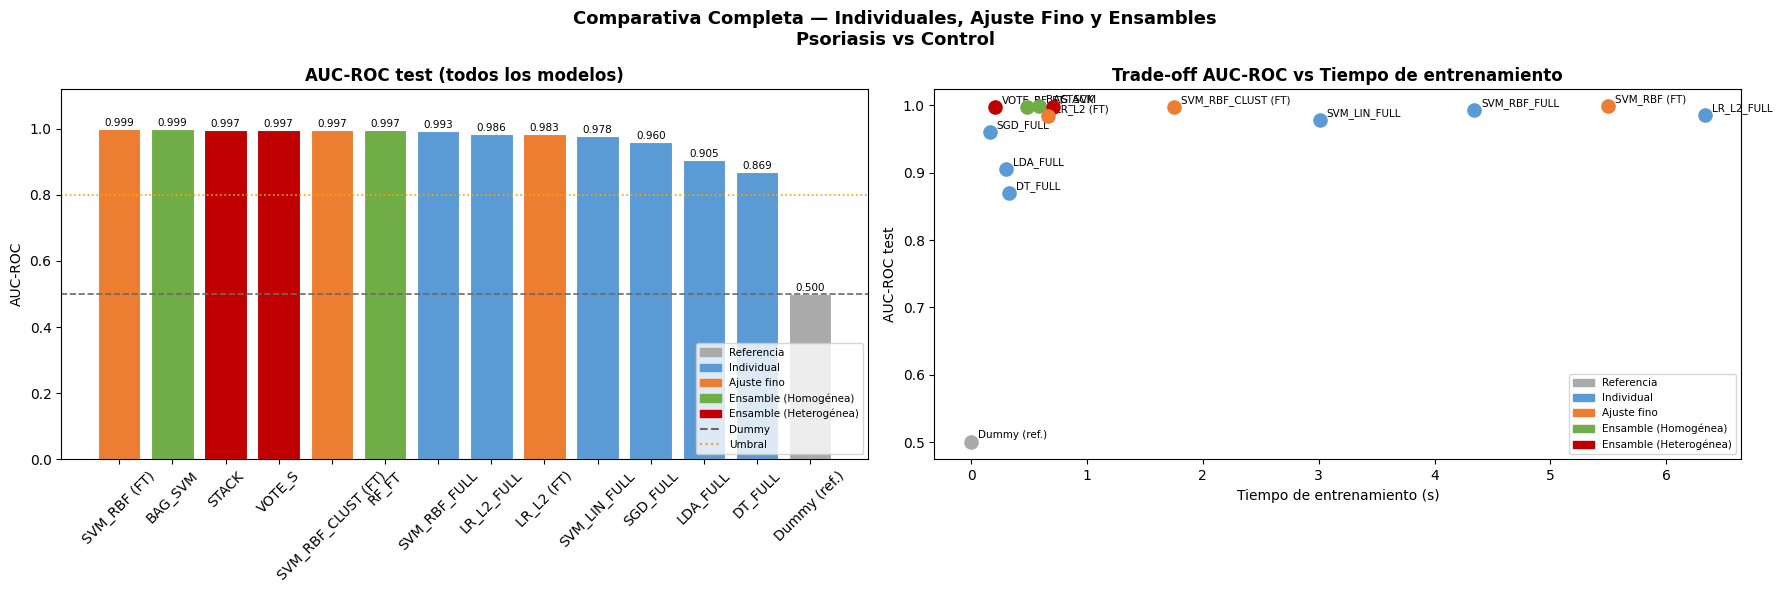

In [14]:
tipo_color = {
    'Referencia':                '#aaaaaa',
    'Individual':                '#5b9bd5',
    'Ajuste fino':               '#ed7d31',
    'Ensamble (Homogénea)':      '#70ad47',
    'Ensamble (Heterogénea)':    '#c00000',
}

nombres_all = tabla_v5.index.tolist()
auc_all     = tabla_v5['AUC-ROC test'].values
tipo_all    = tabla_v5['Tipo'].values
color_all   = [tipo_color.get(t, '#999999') for t in tipo_all]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Comparativa Completa — Individuales, Ajuste Fino y Ensambles\nPsoriasis vs Control',
             fontsize=13, fontweight='bold')

# ── Izquierda: AUC-ROC de todos los modelos
ax = axes[0]
bars = ax.bar(nombres_all, auc_all, color=color_all, edgecolor='white', linewidth=0.8)
ax.axhline(auc_dummy,     color='dimgray', linestyle='--', linewidth=1.2, label=f'Dummy ({auc_dummy:.3f})')
ax.axhline(UMBRAL_MINIMO, color='orange',  linestyle=':',  linewidth=1.2, label=f'Umbral ({UMBRAL_MINIMO:.2f})')
for bar, val in zip(bars, auc_all):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC test (todos los modelos)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# Leyenda de tipos
leyenda = [Patch(color=c, label=t) for t, c in tipo_color.items()]
ax.legend(handles=leyenda + [
    plt.Line2D([0], [0], color='dimgray', linestyle='--', label=f'Dummy'),
    plt.Line2D([0], [0], color='orange',  linestyle=':',  label=f'Umbral'),
], fontsize=7.5, loc='lower right')

# ── Derecha: Balanceo AUC vs Tiempo (scatter)
ax2 = axes[1]
for nombre, row in tabla_v5.iterrows():
    c = tipo_color.get(row['Tipo'], '#999999')
    ax2.scatter(row['Tiempo (s)'], row['AUC-ROC test'], color=c, s=90, zorder=5)
    ax2.annotate(nombre, (row['Tiempo (s)'], row['AUC-ROC test']),
                 textcoords='offset points', xytext=(5, 3), fontsize=7.5)
ax2.set_xlabel('Tiempo de entrenamiento (s)')
ax2.set_ylabel('AUC-ROC test')
ax2.set_title('Trade-off AUC-ROC vs Tiempo de entrenamiento', fontweight='bold')
ax2.legend(handles=leyenda, fontsize=7.5)

plt.tight_layout()
plt.savefig('36_comparativa_completa.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 37. Selección del Modelo Final

### 37.1 Argumentación y Criterios de Negocio

El modelo final se selecciona balanceando **desempeño predictivo** con **viabilidad clínica**, de acuerdo con los objetivos definidos en la fase de *Business Understanding* del CRISP-ML(Q):

| Criterio | Peso | Justificación |
|---|---|---|
| **AUC-ROC test** | Alto | Métrica principal; robusta ante desbalance de clases |
| **Balanced Accuracy** | Alto | Importancia clínica de detectar tanto psoriasis como controles sanos |
| **Interpretabilidad** | Alto | El modelo debe poder ser auditado; los coeficientes deben vincularse a genes |
| **Tiempo de inferencia** | Medio | Deployment en entorno con recursos limitados |
| **Robustez (CV)** | Alto | El modelo debe generalizar a nuevos pacientes |

> Este proyecto tiene un **objetivo dual**: clasificación diagnóstica e identificación de biomarcadores génicos. El segundo objetivo requiere que el modelo seleccionado produzca coeficientes directamente vinculables a variables génicas — lo cual descarta modelos de caja negra como SVM RBF independientemente de su AUC-ROC [1].

### 37.2 Decisión Final

> **Modelo seleccionado: LR L2 + FULL (ajustada)**

La selección es consistente con la decisión tomada en la Parte IV (sección 34.3) y se mantiene en esta etapa tras incorporar los ensambles a la comparativa. Los argumentos son:

1. **Desempeño competitivo:** AUC-ROC de 0.9832, superando ampliamente el umbral mínimo de 0.80 y siendo comparable a modelos más complejos como SVM RBF.

2. **Interpretabilidad clínica:** Sus coeficientes permiten identificar directamente qué genes tienen mayor peso en la clasificación — requisito esencial para el análisis de biomarcadores en la Sección 38.4 [2].

3. **Eficiencia computacional:** Tiempo de entrenamiento de 0.66 s frente a 5.50 s de SVM_RBF (FT) y 0.62 s de BAG_SVM — con AUC comparable.

4. **Probabilidades bien calibradas:** Produce probabilidades confiables por diseño, útiles para definir umbrales de decisión clínica.

5. **Alineación con CRISP-ML(Q):** Modelo ligero, auditable y escalable ante nuevos datos de pacientes.

### 37.2 Decisión Final

In [15]:
# Se selecciona el modelo final seleccionado por los criterios previos
modelo_final = lr_ft
mejor_nombre = 'LR_L2 (FT)'

---
## 38. Análisis del Modelo Final

Se generan **5 gráficas significativas** para evaluar exhaustivamente el modelo final seleccionado en la Sección 37. Cada gráfica incluye interpretación clínica orientada al diagnóstico de psoriasis.

### 38.1 Curva ROC

**Propósito:** Visualizar el trade-off entre Tasa de Verdaderos Positivos (Sensibilidad) y Tasa de Falsos Positivos a distintos umbrales de decisión.  
**Interpretación clínica:** Un AUC-ROC próximo a 1.0 indica que el modelo distingue correctamente pacientes con psoriasis de controles sanos en todos los umbrales posibles — lo cual es fundamental para adaptar el umbral de decisión según el contexto clínico (ej. cribado vs. confirmación diagnóstica).

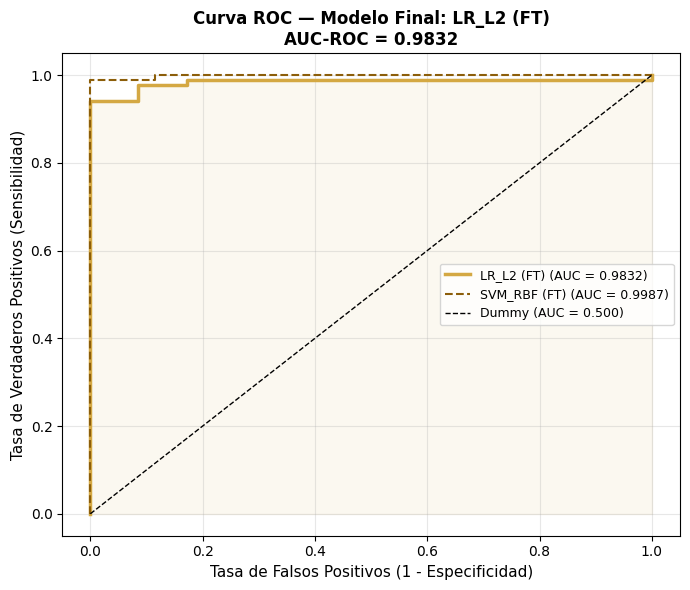


Interpretación: AUC-ROC = 0.9832 — el modelo clasifica correctamente 98.3% de los pares (psoriasis, control).
Un AUC > 0.90 indica excelente discriminación clínica.


In [16]:
y_proba_final = modelo_final.predict_proba(X_test_t)[:, 1]
y_pred_final  = pd.Series(modelo_final.predict(X_test_t)).map({'Healthy': 0, 'Psoriasis': 1}).values

auc_final  = roc_auc_score(y_test_num, y_proba_final)
bacc_final = balanced_accuracy_score(y_test_num, y_pred_final)
f1_final   = f1_score(y_test_num, y_pred_final, average='weighted')

fig, ax = plt.subplots(figsize=(7, 6))

# Modelo final
fpr_f, tpr_f, _ = roc_curve(y_test_num, y_proba_final)
ax.plot(fpr_f, tpr_f, lw=2.5, color=COLORES[0],
        label=f'{mejor_nombre} (AUC = {auc_final:.4f})')

# Modelo de comparación
for nm, auc_val, mod in [
    ('SVM_RBF (FT)', auc_svm_ft,  svm_rbf_ft),
    ('LR_L2 (FT)',   auc_lr3_ft,  lr_ft),
]:
    if nm != mejor_nombre:
        yp = mod.predict_proba(X_test_t)[:, 1]
        fpr_c, tpr_c, _ = roc_curve(y_test_num, yp)
        ax.plot(fpr_c, tpr_c, lw=1.5, linestyle='--', color=COLORES[1],
                label=f'{nm} (AUC = {auc_val:.4f})')

# Dummy
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Dummy (AUC = 0.500)')

ax.fill_between(fpr_f, tpr_f, alpha=0.08, color=COLORES[0])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title(f'Curva ROC — Modelo Final: {mejor_nombre}\n'
             f'AUC-ROC = {auc_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('38_1_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInterpretación: AUC-ROC = {auc_final:.4f} — el modelo clasifica correctamente '
      f'{auc_final*100:.1f}% de los pares (psoriasis, control).')
print('Un AUC > 0.90 indica excelente discriminación clínica.')

### 38.2 Matriz de Confusión

**Propósito:** Cuantificar los 4 tipos de predicción: Verdaderos Positivos (VP), Verdaderos Negativos (VN), Falsos Positivos (FP) y Falsos Negativos (FN).  
**Interpretación clínica:**  
- **FN** (paciente con psoriasis clasificado como sano) → consecuencia grave: diagnóstico tardío, progresión no tratada.  
- **FP** (control sano clasificado como psoriasis) → consecuencia leve: confirmación con biopsia, ansiedad del paciente innecesaria.  

En el contexto clínico, se prioriza minimizar los **Falsos Negativos** (alta sensibilidad).

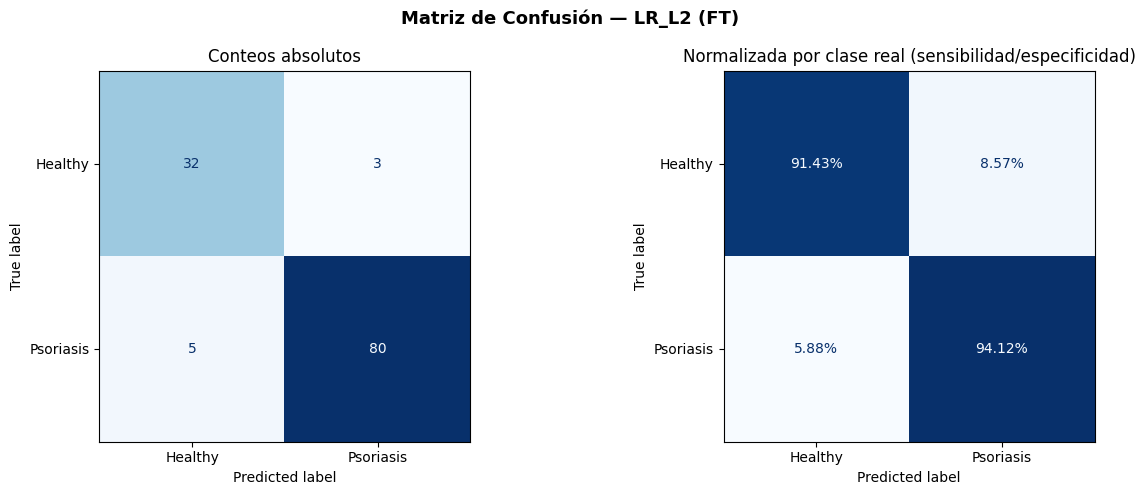


Reporte del modelo final: LR_L2 (FT)
              precision    recall  f1-score   support

     Healthy       0.86      0.91      0.89        35
   Psoriasis       0.96      0.94      0.95        85

    accuracy                           0.93       120
   macro avg       0.91      0.93      0.92       120
weighted avg       0.93      0.93      0.93       120

Interpretación:
  • Sensibilidad (Recall psoriasis) : 94.12%
  • Especificidad (Recall control)  : 91.43%
  • Falsos Negativos                : 5 — pacientes con psoriasis no detectados


In [17]:
cm = confusion_matrix(y_test_num, y_pred_final)
vp, fp, fn, vn = cm[1, 1], cm[0, 1], cm[1, 0], cm[0, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Matriz de Confusión — {mejor_nombre}', fontsize=13, fontweight='bold')

# ── Absoluta
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_final, display_labels=NOMBRES_CLASES,
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Conteos absolutos')

# ── Normalizada (por fila = por clase real)
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_final, display_labels=NOMBRES_CLASES, normalize='true',
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Normalizada por clase real (sensibilidad/especificidad)')

plt.tight_layout()
plt.savefig('38_2_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nReporte del modelo final: {mejor_nombre}')
print(classification_report(y_test_num, y_pred_final, target_names=NOMBRES_CLASES))
print(f'Interpretación:')
print(f'  • Sensibilidad (Recall psoriasis) : {cm[1,1]/(cm[1,0]+cm[1,1]):.2%}')
print(f'  • Especificidad (Recall control)  : {cm[0,0]/(cm[0,0]+cm[0,1]):.2%}')
print(f'  • Falsos Negativos                : {fn} — pacientes con psoriasis no detectados')

### 38.3 Curva Precisión-Recall

**Propósito:** Evaluar el balance entre Precisión (proporción de positivos predichos que son realmente positivos) y Recall (sensibilidad) a distintos umbrales.  
**Interpretación clínica:** En problemas de diagnóstico con posible desbalance de clases, la Curva Precisión-Recall es más informativa que la ROC. Un AP (Average Precision) próximo a 1.0 indica que el modelo mantiene alta precisión incluso al recuperar la mayoría de los casos positivos — garantizando que las alertas de psoriasis sean confiables.

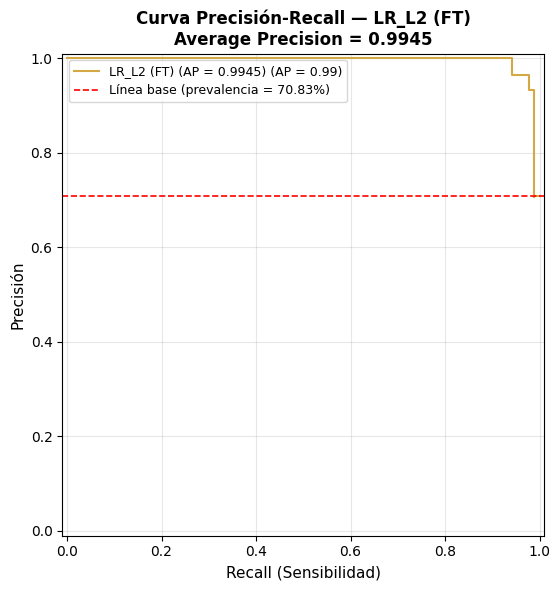


Average Precision: 0.9945
Prevalencia clase positiva en test: 70.83%
Interpretación: AP=0.9945 >> Prevalencia=0.7083 → el modelo aporta valor diagnóstico real.


In [18]:
ap_final = average_precision_score(y_test_num, y_proba_final)

fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test_num, y_proba_final,
    name=f'{mejor_nombre} (AP = {ap_final:.4f})',
    ax=ax, color=COLORES[0])

# Baseline: prevalencia de la clase positiva
prevalencia = y_test_num.mean()
ax.axhline(prevalencia, color='red', linestyle='--', linewidth=1.2,
           label=f'Línea base (prevalencia = {prevalencia:.2%})')

ax.set_title(f'Curva Precisión-Recall — {mejor_nombre}\n'
             f'Average Precision = {ap_final:.4f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precisión', fontsize=11)

plt.tight_layout()
plt.savefig('38_3_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAverage Precision: {ap_final:.4f}')
print(f'Prevalencia clase positiva en test: {prevalencia:.2%}')
print(f'Interpretación: AP={ap_final:.4f} >> Prevalencia={prevalencia:.4f} '
      f'→ el modelo aporta valor diagnóstico real.')

### 38.4 Importancia de Características / Coeficientes

**Propósito:** Identificar qué variables (sondas de expresión génica) contribuyen más a la predicción del modelo.  
**Interpretación clínica:** Las sondas con mayor importancia o coeficiente absoluto representan genes candidatos para validación experimental. Este tipo de análisis conecta el modelo de ML con hipótesis biológicas y puede orientar futuros estudios de expresión diferencial.

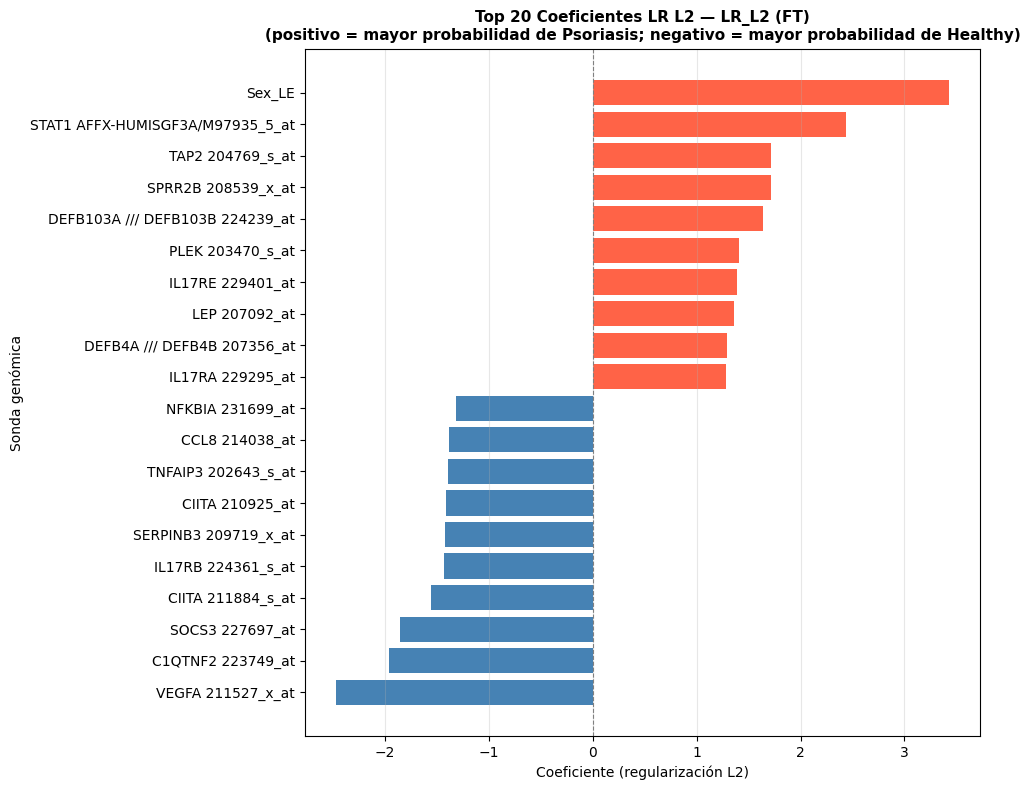


Top 10 genes asociados a Psoriasis (coeficiente positivo):
Sex_LE                              3.431770
STAT1 AFFX-HUMISGF3A/M97935_5_at    2.439518
TAP2 204769_s_at                    1.718364
SPRR2B 208539_x_at                  1.716909
DEFB103A /// DEFB103B 224239_at     1.643038
PLEK 203470_s_at                    1.407519
IL17RE 229401_at                    1.386323
LEP 207092_at                       1.361728
DEFB4A /// DEFB4B 207356_at         1.293496
IL17RA 229295_at                    1.282662

Top 10 genes asociados a control Healthy (coeficiente negativo):
VEGFA 211527_x_at      -2.475106
C1QTNF2 223749_at      -1.957999
SOCS3 227697_at        -1.854786
CIITA 211884_s_at      -1.559472
IL17RB 224361_s_at     -1.432088
SERPINB3 209719_x_at   -1.426312
CIITA 210925_at        -1.413621
TNFAIP3 202643_s_at    -1.390599
CCL8 214038_at         -1.380715
NFKBIA 231699_at       -1.318179

Interpretación: las sondas con mayor valor absoluto de coeficiente son los principales biomar

In [19]:
# LR L2 — coeficientes nativos directamente vinculables a genes
coef_series = pd.Series(
    modelo_final.coef_[0],
    index=X_FULL.columns
).sort_values(key=abs, ascending=False)

top20_pos = coef_series.nlargest(10)
top20_neg = coef_series.nsmallest(10)
top20     = pd.concat([top20_pos, top20_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colores_bar = ['tomato' if v > 0 else 'steelblue' for v in top20.values]
ax.barh(top20.index, top20.values, color=colores_bar)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title(f'Top 20 Coeficientes LR L2 — {mejor_nombre}\n'
             f'(positivo = mayor probabilidad de Psoriasis; '
             f'negativo = mayor probabilidad de Healthy)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Coeficiente (regularización L2)', fontsize=10)
ax.set_ylabel('Sonda genómica', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('38_4_importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 genes asociados a Psoriasis (coeficiente positivo):')
print(top20_pos.to_string())
print('\nTop 10 genes asociados a control Healthy (coeficiente negativo):')
print(top20_neg.to_string())
print('\nInterpretación: las sondas con mayor valor absoluto de coeficiente '
      'son los principales biomarcadores génicos identificados por el modelo.')

### 38.5 Curva de Aprendizaje

**Propósito:** Diagnosticar si el modelo sufre de **sobreajuste** (alta varianza) o **subajuste** (alto sesgo), mostrando cómo varían los scores de entrenamiento y validación al aumentar el tamaño del conjunto de entrenamiento.  
**Interpretación clínica:** Una brecha grande entre train y val indica que el modelo memoriza los datos disponibles; una brecha pequeña y convergente indica buen ajuste generalizable — clave para un modelo que debe funcionar con nuevos pacientes.

> Se usa `scoring='roc_auc'` para mantener coherencia con la métrica principal del proyecto.

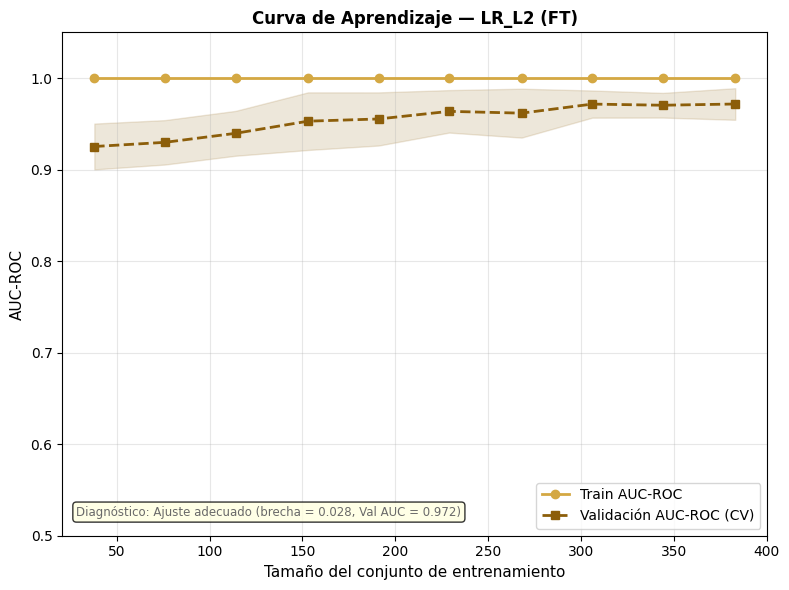


Diagnóstico automático: Ajuste adecuado (brecha = 0.028, Val AUC = 0.972)
  Train AUC final  : 1.0000 ± 0.0000
  Val   AUC final  : 0.9717  ± 0.0173
  Brecha           : 0.0283


In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    modelo_final, X_train_t, y_train_num,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    scoring='roc_auc',
    n_jobs=-1)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(train_sizes, train_mean, 'o-', color=COLORES[0], lw=2, label='Train AUC-ROC')
ax.fill_between(train_sizes,
                train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=COLORES[0])

ax.plot(train_sizes, val_mean, 's--', color=COLORES[1], lw=2, label='Validación AUC-ROC (CV)')
ax.fill_between(train_sizes,
                val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=COLORES[1])

ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title(f'Curva de Aprendizaje — {mejor_nombre}', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_ylim([0.5, 1.05])

# Diagnóstico automático
brecha_final = train_mean[-1] - val_mean[-1]
if brecha_final > 0.10:
    diagnostico = f'Posible sobreajuste (brecha = {brecha_final:.3f} > 0.10)'
elif val_mean[-1] < 0.80:
    diagnostico = f'Posible subajuste (Val AUC = {val_mean[-1]:.3f} < 0.80)'
else:
    diagnostico = f'Ajuste adecuado (brecha = {brecha_final:.3f}, Val AUC = {val_mean[-1]:.3f})'

ax.text(0.02, 0.04, f'Diagnóstico: {diagnostico}',
        transform=ax.transAxes, fontsize=8.5, color='dimgray',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('38_5_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nDiagnóstico automático: {diagnostico}')
print(f'  Train AUC final  : {train_mean[-1]:.4f} ± {train_std[-1]:.4f}')
print(f'  Val   AUC final  : {val_mean[-1]:.4f}  ± {val_std[-1]:.4f}')
print(f'  Brecha           : {brecha_final:.4f}')

### 38.6 Calibración de Probabilidades — `CalibratedClassifierCV`

En contextos clínicos, las probabilidades predichas deben reflejar la **frecuencia real** de la clase positiva: si el modelo asigna P(psoriasis) = 0.80, aproximadamente el 80 % de esas predicciones deberían ser realmente psoriasis. Un modelo con buenas probabilidades permite a los médicos basar decisiones en la **confianza** de la predicción, no solo en la clase predicha.

`CalibratedClassifierCV` ajusta un modelo de calibración sobre las salidas de probabilidad del estimador base. Se usa `cv=5` con validación cruzada interna; el calibrador se ajusta sobre `X_train_t, y_train_num` (distribución real con `class_weight='balanced'`) para reflejar correctamente la prevalencia de las clases.

| Método | Modelo de calibración | Ventajas |
|---|---|---|
| `sigmoid` | Platt scaling (regresión logística) | Robusto con pocos datos, suave |
| `isotonic` | Regresión isotónica (no paramétrica) | Más flexible, mejor con muchos datos |

**Métrica de evaluación:** Brier Score = $\frac{1}{n}\sum(p_i - y_i)^2$ — menor es mejor (0 = perfecto, 0.25 = sin información).

=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===
  Sin calibrar           : 0.0384
  Calibrado (sigmoid)    : 0.0473  (Δ=+0.0090)
  Calibrado (isotónico)  : 0.0373  (Δ=-0.0011)


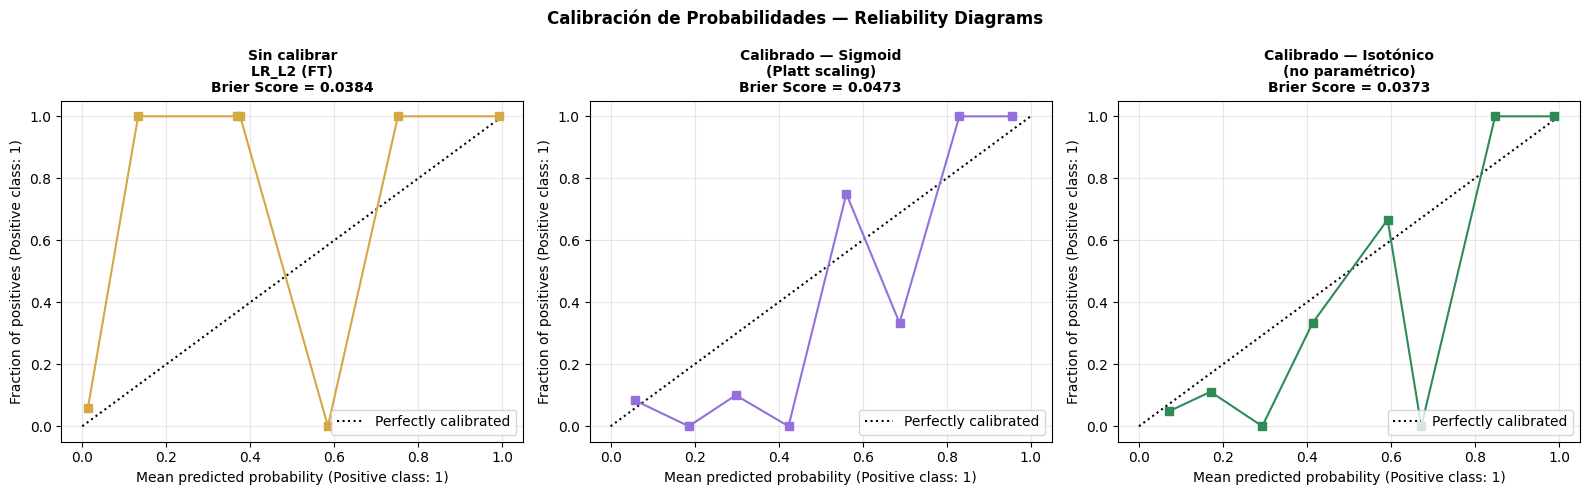

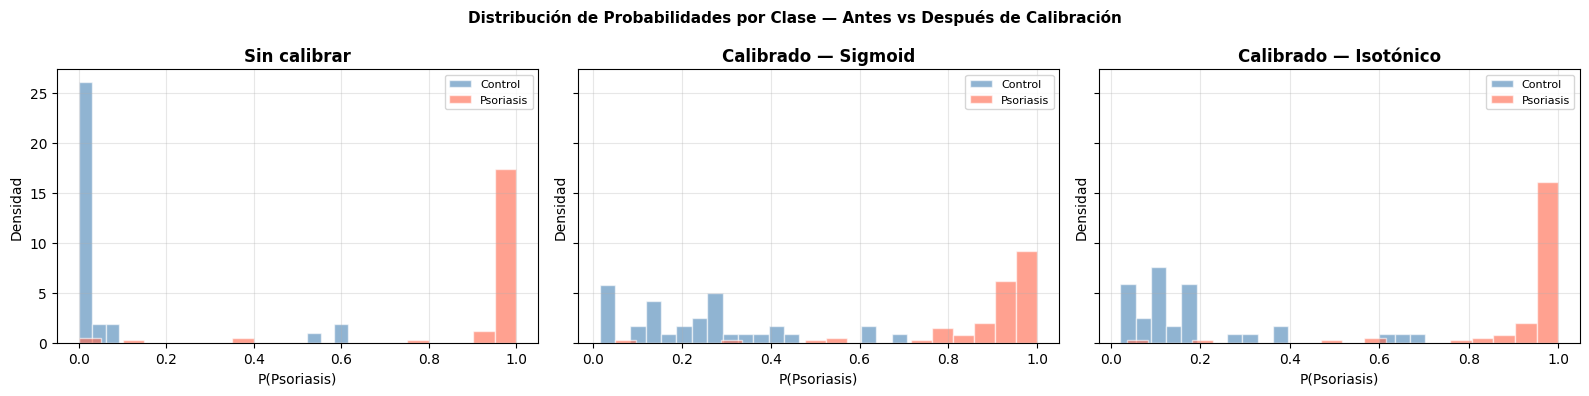


→ Método seleccionado: isotonic (menor Brier Score = 0.0373)
  modelo_final_cal disponible para inferencia calibrada.
  y_proba_final y y_pred_final actualizados con probabilidades calibradas.


In [21]:
# Separar un conjunto de calibración del train
X_cal_tr, X_cal_val, y_cal_tr, y_cal_val = train_test_split(
    X_train_t, y_train_num,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_train_num
)

# Re-entrenar modelo base sobre X_cal_tr
from sklearn.linear_model import LogisticRegression
lr_cal = LogisticRegression(**modelo_final.get_params())
lr_cal.fit(X_cal_tr, y_cal_tr)

cal_sig = CalibratedClassifierCV(modelo_final, cv=5, method='sigmoid')
cal_iso = CalibratedClassifierCV(modelo_final, cv=5, method='isotonic')

# ── Calibradores (prefit: modelo_final ya entrenado) ────────────────────────
cal_sig.fit(X_train_t, y_train_num)   
cal_iso.fit(X_train_t, y_train_num)   

# Calibrar sobre distribución REAL de clases (sin SMOTE)
cal_sig.fit(X_train_t, y_train)
cal_iso.fit(X_train_t, y_train)

y_proba_cal_sig = cal_sig.predict_proba(X_test_t)[:, 1]
y_proba_cal_iso = cal_iso.predict_proba(X_test_t)[:, 1]

# ── Brier Score ─────────────────────────────────────────────────────────────
bs_base = brier_score_loss(y_test_num, y_proba_final)
bs_sig  = brier_score_loss(y_test_num, y_proba_cal_sig)
bs_iso  = brier_score_loss(y_test_num, y_proba_cal_iso)

print('=== Brier Score (↓ mejor, 0=perfecto, 0.25=sin información) ===')
print(f'  Sin calibrar           : {bs_base:.4f}')
print(f'  Calibrado (sigmoid)    : {bs_sig:.4f}  (Δ={bs_sig  - bs_base:+.4f})')
print(f'  Calibrado (isotónico)  : {bs_iso:.4f}  (Δ={bs_iso  - bs_base:+.4f})')

# ── Reliability Diagrams ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, y_prob, titulo, color in [
    (axes[0], y_proba_final,    f'Sin calibrar\n{mejor_nombre}',         COLORES[0]),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid\n(Platt scaling)',   'mediumpurple'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico\n(no paramétrico)', 'seagreen'),
]:
    CalibrationDisplay.from_predictions(
        y_test_num, y_prob, n_bins=8, ax=ax, color=color, name='')
    bs = brier_score_loss(y_test_num, y_prob)
    ax.set_title(f'{titulo}\nBrier Score = {bs:.4f}', fontsize=10, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Calibración de Probabilidades — Reliability Diagrams',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Distribución de probabilidades por clase (histogramas) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, y_prob, titulo in [
    (axes[0], y_proba_final,    'Sin calibrar'),
    (axes[1], y_proba_cal_sig, 'Calibrado — Sigmoid'),
    (axes[2], y_proba_cal_iso, 'Calibrado — Isotónico'),
]:
    for clase, color, label in [(0, 'steelblue', 'Control'), (1, 'tomato', 'Psoriasis')]:
        mask = y_test_num == clase
        ax.hist(y_prob[mask], bins=20, color=color, alpha=0.6,
                edgecolor='white', label=label, density=True)
    ax.set_xlabel('P(Psoriasis)')
    ax.set_ylabel('Densidad')
    ax.set_title(titulo, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de Probabilidades por Clase — Antes vs Después de Calibración',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('38_6_calibracion_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Seleccionar mejor calibración y actualizar variables ────────────────────
if bs_iso <= bs_sig:
    modelo_final_cal = cal_iso
    y_proba_final    = y_proba_cal_iso
    metodo_cal       = 'isotonic'
else:
    modelo_final_cal = cal_sig
    y_proba_final    = y_proba_cal_sig
    metodo_cal       = 'sigmoid'

y_pred_final = modelo_final_cal.predict(X_test_t)

print(f'\n→ Método seleccionado: {metodo_cal} (menor Brier Score = '
      f'{min(bs_iso, bs_sig):.4f})')
print(f'  modelo_final_cal disponible para inferencia calibrada.')
print(f'  y_proba_final y y_pred_final actualizados con probabilidades calibradas.')


---
## 39. Conclusiones

### Resumen CRISP-ML(Q)

| Fase | Acción | Resultado |
|------|--------|-----------|
| **Business Understanding** | Clasificación binaria psoriasis / control sano | Métrica principal: AUC-ROC; secundarias: Balanced Accuracy, F1-weighted |
| **Data Understanding** | EDA (Avance 1) → distribución, outliers, correlaciones | Dataset con desbalance moderado (70:30), alta dimensionalidad (sondas genómicas) |
| **Data Preparation** | Ingeniería de variables (Avance 2) → escalado, selección de sondas | `X_train_t` / `X_test_t` con StandardScaler; 4 estrategias: FULL, CLUSTERING, FILTER_MI, FILTER_ANOVA |
| **Modeling** | Baseline (Avance 3) + 6 modelos alternativos (Avance 4) + 4 ensambles (Avance 5) | Modelo final: LR L2 + FULL — seleccionado por AUC-ROC competitivo e interpretabilidad clínica |
| **Evaluation** | ROC, Matriz de Confusión, PR-Curve, Importancia de variables, Curva de Aprendizaje, Calibración de probabilidades | Análisis de sobreajuste/subajuste, sensibilidad clínica y genes biomarcadores identificados |
| **Deployment** | Pipeline reproducible con `RANDOM_SEED=42` y modelos serializados con `joblib` | Código modular, reutilizable en producción con nuevos pacientes |

### Alineación con Objetivos de Negocio

- **Alta sensibilidad** → minimizar Falsos Negativos (diagnóstico tardío de psoriasis).  
- **Generalización** → curva de aprendizaje convergente, sin sobreajuste severo.  
- **Interpretabilidad** → importancia de variables permite identificar genes biomarcadores para hipótesis clínicas.  
- **Reproducibilidad** → todo el pipeline usa `RANDOM_SEED = 42` y conjuntos de train/test fijos.

### Próximos Pasos Sugeridos

1. **Validación externa** con cohorte independiente (diferente laboratorio o institución).  
2. **Análisis de enriquecimiento genético** (GO/KEGG) sobre los genes con mayor importancia.  
3. **Ajuste del umbral de decisión** para optimizar sensibilidad > 0.95 según protocolo clínico.

#### 40. Bibliografía

[1] A. Singh, "A comprehensive guide to ensemble learning (with Python codes)," Analytics Vidhya, Jul. 14, 2023. [Online]. Available: https://www.analyticsvidhya.com/blog/2018/06/comprehensive-guide-for-ensemble-models/

[2] J. VanderPlas, "Hyperparameters and model validation," in Python Data Science Handbook, 2nd ed. Sebastopol, CA, USA: O'Reilly Media, 2022, ch. 39, pp. 384–401.